In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset
import torch.nn.functional as torch_F # avoid import problems becasue F is used as a variable

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *
from utils import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

/home/waasiq/miniconda3/envs/alpha/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

In [3]:
dfs = get_dfs(os.path.dirname(os.getcwd()))
static_df = create_static_df(dfs)
medication_df = create_medication_df(dfs)
vitals_ca, vitals_lab = create_vitals_df(dfs)
biopsy_df = dfs['biopsy']

ts_data = create_ts_data(vitals_ca, vitals_lab, medication_df, merge_lab=True, merge_med=True, static_df=static_df)

#notes = create_notes_df(dfs, filename='../data/embeddings/emb_gte.npy')
notes = create_notes_df(dfs, filename='../data/embeddings/emb_med_gte_simcse_en_ger.npy')
#notes = create_notes_df(dfs, filename=None)

eligible_patient_ids = get_valid_patient_ids(static_df=static_df, ts_data=ts_data, notes_df=notes, require_notes=True)
datapoints_limit = len(eligible_patient_ids)
#datapoints_limit = 320 * 5

dataset_splits = create_dataset_splits(
    static_df=static_df,
    ts_data=ts_data,
    notes_df=notes,
    biopsy_df=biopsy_df,
    train_size=0.8,
    test_size=0.2,
    max_patients=datapoints_limit,
    require_notes=True,
    random_state=42,
)

full_dataset = dataset_splits['full']
train_dataset = dataset_splits['train']
test_dataset = dataset_splits['test']
ts_scaler = train_dataset.ts_scaler
static_scaler = train_dataset.scaler

Unique patients in medication: 3335
Removing patients that are not in static_df
Unique patients in clinical assessments: 3296
Average entries per patient 78.9
Unique patients in clinical assessments: 3465
Removing patients that are not in static_df
Unique patients in clinical assessments: 3423
Average entries per patient 61.16155419222904
Unique patients in lab df: 3460
Removing patients that are not in static_df
Unique patients in lab df: 3410
Average entries per patient 472.2140762463343
Reading notes from exams.csv
Found 206509 texts
Loading 215137 texts from clinical assessments
Concatenated texts and deleted NaNs, final count: 367140
Average texts per patient: 106.9


In [4]:
batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
full_dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

#vanilla_lstm = VanillaTimeSeriesEncoder()
att_encoder = TimeAwareAttentionEncoder(use_temporal_attention=True)
model = MultiModal(att_encoder, categorical_cardinalities=train_dataset.categorical_cardinalities, use_static=True, use_notes=True).to(device)
predict_steps_ahead = 1
lambda_corr = 0.0
lambda_modality_mi = 0.0
lambda_feature_loss = 0.0

In [5]:
criterion = nn.MSELoss(reduction='none')
optimizer = optim.Adam(model.parameters(), lr=0.0003)

feature_decoders = FeatureDecoders(CONFIG['lstm_hidden_size'], CONFIG).to(device)
feature_decoder_optimizer = optim.Adam(feature_decoders.parameters(), lr=0.0003)

num_epochs = 10

with tqdm(total=num_epochs * len(train_dataloader), desc="Training", leave=True) as pbar:
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        total_valid_points = 0.0
        model.train()
        
        for batch_idx, batch in enumerate(train_dataloader):
            cat_features = batch['static_categorical_features'].to(device)
            num_features_input = batch['static_numerical_features'].to(device)
            
            # full_seq shape: (B, T, F)
            full_seq = batch['ts_features'].to(device)
            timesteps = batch['timesteps'].to(device)     # (B, T)
            value_mask_full = batch['value_mask'].to(device)  # (B, T, F)
            mask = batch['mask'].to(device)               # (B, T) => True=valid data, False=pad
            B, T, F = full_seq.shape

            notes_embeddings = batch['notes_embeddings'].to(device)
            notes_timesteps = batch['notes_timesteps'].to(device)
            notes_mask = batch['notes_mask'].to(device)

            # We need at least 2 timesteps to do 1-step-ahead training
            if T <= predict_steps_ahead:
                continue
            
            # x => all steps except the last (for input)
            # shape => (B, T-1, F)
            input_seq = full_seq[:, :-predict_steps_ahead, :]
            
            # timesteps => we also omit the last one, shape => (B, T-1)
            input_timesteps = timesteps[:, :-predict_steps_ahead]
            
            # Elapsed times => difference between consecutive steps
            # then take only the first (T - predict_steps_ahead) deltas
            delta_times = timesteps[:, 1:] - timesteps[:, :-1]   # (B, T-1)
            elapsed_times = delta_times[:, : (T - predict_steps_ahead)]
            
            input_mask = mask[:, :-predict_steps_ahead]  # (B, T-1)
            input_value_mask = value_mask_full[:, :-predict_steps_ahead, :]
            
            # shape => (B, T-1, F)
            optimizer.zero_grad()
            feature_decoder_optimizer.zero_grad()
            
            outputs, hidden_states, _, static_embedding = model(
                x=input_seq,
                elapsed_times=elapsed_times,
                timesteps=input_timesteps,
                notes_embeddings=notes_embeddings,
                notes_timesteps=notes_timesteps,
                static_features=(cat_features, num_features_input),
                mask=input_mask,
                value_mask=input_value_mask,
                notes_mask=notes_mask
            )
            
            # target => all steps from index 1..T-predict_steps_ahead
            # shape => (B, T-predict_steps_ahead, F)
            target_seq = full_seq[:, predict_steps_ahead:, :]
            
            # valid_mask => the same region
            valid_mask = value_mask_full[:, predict_steps_ahead:, :]
            
            raw_loss = criterion(outputs, target_seq)  # (B, T-1, F)
            masked_loss = raw_loss * valid_mask.float()   # elementwise
            valid_points = valid_mask.float().sum()    # total count of valid features
            
            accum_loss = masked_loss.sum()
            final_loss = accum_loss / valid_points if valid_points > 0 else torch.tensor(0.0, device=device)

            last_hidden = get_last_valid_step(hidden_states, input_mask)
            last_notes = get_last_valid_note_embedding(notes_embeddings, notes_mask)
            last_ts = get_last_valid_step(full_seq, mask)
            decorr_loss = correlation_loss(last_hidden) # compute corr loss on last hidden state 
            
            mi_loss = modality_mi_loss(
                last_hidden,
                static_embedding,         # Static embeddings from model output
                last_notes
            )

            feature_preds, masks = feature_decoders(last_hidden)

            feat_pred_loss = feature_prediction_loss(
                feature_preds, 
                masks,
                cat_features,  # Your categorical features
                num_features_input,  # Your numerical features
                last_ts
            )


            batch_loss = final_loss + lambda_corr * decorr_loss + lambda_modality_mi * mi_loss # + lambda_feature_loss * feat_pred_loss

            batch_loss.backward()
            optimizer.step()
            feature_decoder_optimizer.step()

            # For logging
            epoch_loss += final_loss.item() * valid_points.item()
            total_valid_points += valid_points.item()
            pbar.update(1)
            if total_valid_points > 0:
                avg_loss = epoch_loss / total_valid_points
                pbar.set_postfix({
                    'Epoch': f"{epoch+1}/{num_epochs}",
                    'Avg Loss so far': f"{avg_loss:.4f}",
                    'Correlation Loss': f"{decorr_loss.item():.4f}",
                    'Modality MI Loss': f"{mi_loss.item():.4f}",
                })

print("Training completed.")
torch.save(model.state_dict(), "../models/full10ep.pt")

Training:   0%|          | 0/1700 [00:00<?, ?it/s]

Training: 100%|██████████| 1700/1700 [18:11<00:00,  1.56it/s, Epoch=10/10, Avg Loss so far=0.3171, Correlation Loss=16064.6504, Modality MI Loss=0.3153]

Training completed.


In [6]:
model.eval()
criterion = nn.MSELoss(reduction='none')

total_loss = 0.0
total_valid_points = 0.0

num_features = len(CONFIG['ts_features'])
feature_mae_sum = torch.zeros(num_features, device=device)
feature_count = torch.zeros(num_features, device=device)

total_decorr_loss = 0.0
num_samples = len(test_dataloader) * batch_size

with torch.no_grad():
    for batch in test_dataloader:
        cat_features = batch['static_categorical_features'].to(device)
        num_features_input = batch['static_numerical_features'].to(device)

        full_seq = batch['ts_features'].to(device)         # (B, T, F)
        timesteps = batch['timesteps'].to(device)          # (B, T)
        value_mask_full = batch['value_mask'].to(device)   # (B, T, F)

        notes_embeddings = batch['notes_embeddings'].to(device)
        notes_timesteps = batch['notes_timesteps'].to(device)
        notes_mask = batch['notes_mask'].to(device)        # (B, max_notes_length)

        B, T, F = full_seq.shape

        # Skip if sequence is too short for predict_steps_ahead
        if T <= predict_steps_ahead:
            continue

        input_seq = full_seq[:, :-predict_steps_ahead, :]   # (B, T - N, F)
        # Target => steps [N .. end]
        target_seq = full_seq[:, predict_steps_ahead:, :]   # (B, T - N, F)

        # Elapsed times => difference between consecutive steps
        delta_times = timesteps[:, 1:] - timesteps[:, :-1]   # (B, T-1)
        # Keep only the first (T - N) for the input sequence
        elapsed_times = delta_times[:, : (T - predict_steps_ahead)]

        input_value_mask = value_mask_full[:, :-predict_steps_ahead, :]

        # Valid mask for the target timesteps
        valid_mask = value_mask_full[:, predict_steps_ahead:, :]  # (B, T - N, F)


        outputs, hidden_states, _, _ = model(
            x=input_seq,
            elapsed_times=elapsed_times,
            timesteps=timesteps[:, :-predict_steps_ahead],
            notes_embeddings=notes_embeddings,
            notes_timesteps=notes_timesteps,
            static_features=(cat_features, num_features_input),
            mask=batch['mask'][:, :-predict_steps_ahead].to(device),  # (B, T - N)
            value_mask=input_value_mask,
            notes_mask=notes_mask
        )
        # outputs => (B, T - N, F)

        raw_loss = criterion(outputs, target_seq)  # (B, T - N, F)
        masked_loss = raw_loss * valid_mask.float()  # broadcast `loss_mask` => (1,1,F)
        valid_points = valid_mask.float().sum()

        batch_loss_sum = masked_loss.sum()
        if valid_points > 0:
            batch_loss = batch_loss_sum / valid_points
        else:
            batch_loss = 0.0


        total_loss += batch_loss.item() * valid_points
        total_valid_points += valid_points

        # Compute decorrelation loss on last representation (B, D)
        last_rep = get_last_valid_step(hidden_states, batch['mask'][:, :-predict_steps_ahead].to(device))
        batch_decorr_loss = correlation_loss(last_rep)

        total_decorr_loss += batch_decorr_loss.item()

        B_, TmN, F_ = outputs.shape  # TmN = T - N
        outputs_2d = outputs.reshape(B_ * TmN, F_).cpu().numpy()
        target_2d = target_seq.reshape(B_ * TmN, F_).cpu().numpy()

        outputs_unscaled = ts_scaler.inverse_transform(outputs_2d)  # (B_*TmN, F)
        target_unscaled = ts_scaler.inverse_transform(target_2d)

        abs_error = np.abs(outputs_unscaled - target_unscaled)  # (B_*TmN, F)
        abs_error_t = torch.from_numpy(abs_error).float().to(device)

        valid_mask_2d = valid_mask.reshape(B_ * TmN, F_).float().to(device)
        feature_mae_sum += (abs_error_t * valid_mask_2d).sum(dim=0)
        feature_count += valid_mask_2d.sum(dim=0)

if total_valid_points > 0:
    avg_test_loss = total_loss / total_valid_points
else:
    avg_test_loss = 0.0

avg_decorr_loss = total_decorr_loss / num_samples

per_feature_mae = feature_mae_sum / (feature_count + 1e-8)

print(f"Evaluation (predict_steps_ahead={predict_steps_ahead}):")
print("Per-feature (Unscaled) MAE:")
for f_name, f_mae in zip(CONFIG['ts_features'], per_feature_mae.tolist()):
    print(f"{f_name}: MAE = {f_mae:.4f}")

print('-' * 50)
print(f"Overall Test Set Average Loss (scaled MSE): {avg_test_loss:.4f}")
print(f"Average Decorrelation Loss (last representation): {avg_decorr_loss:.4f}")

Evaluation (predict_steps_ahead=1):
Per-feature (Unscaled) MAE:
bp_sys: MAE = 9.1794
bp_dia: MAE = 6.3888
weight: MAE = 3.6436
urine_volume: MAE = 388.5616
hr: MAE = 6.6428
temperature: MAE = 0.3213
diuresis_time: MAE = 0.6703
creatinine: MAE = 0.3242
leukocyte: MAE = 1.6171
proteinuria: MAE = 121.3837
crphp: MAE = 1.4656
egfr: MAE = 5.3189
acr: MAE = 139.0187
Tacrolimus: MAE = 2.1705
Methylprednisolon: MAE = 25.7854
Ciclosporin: MAE = 21.0374
--------------------------------------------------
Overall Test Set Average Loss (scaled MSE): 0.4303
Average Decorrelation Loss (last representation): 90.4466


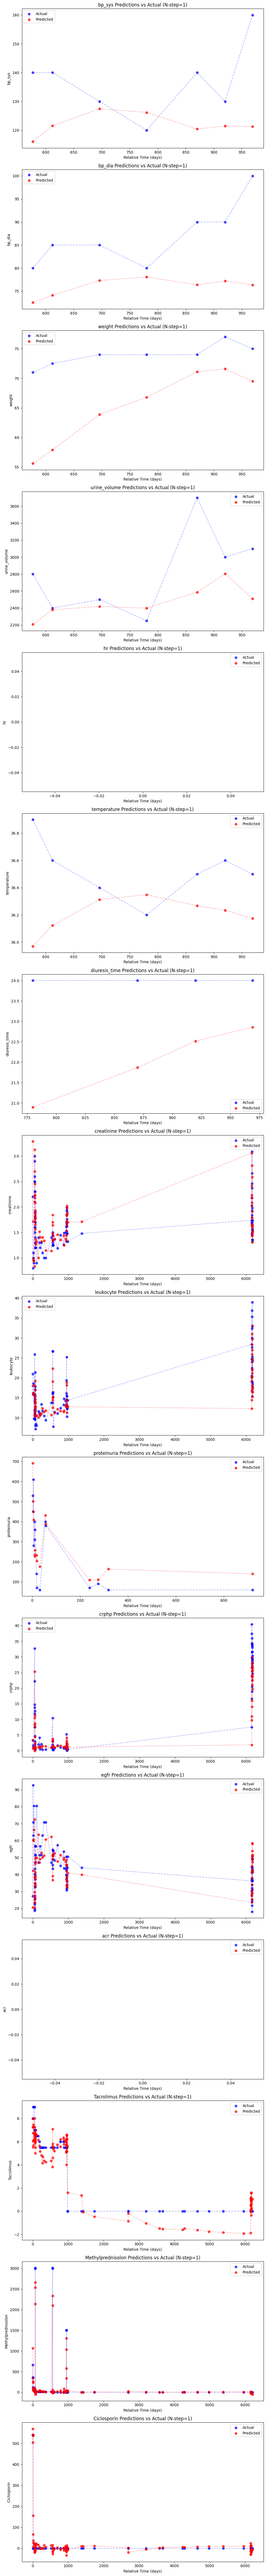

In [7]:
model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        cat_features = batch['static_categorical_features'].to(device)
        num_features = batch['static_numerical_features'].to(device)

        full_seq = batch['ts_features'].to(device)       # (B, T, F)
        timesteps = batch['timesteps'].to(device)        # (B, T)
        value_mask_full = batch['value_mask'].to(device) # (B, T, F)

        notes_embeddings = batch['notes_embeddings'].to(device)
        notes_timesteps = batch['notes_timesteps'].to(device)
        notes_mask = batch['notes_mask'].to(device)

        B, T, F = full_seq.shape

        # Skip if sequence is too short for the desired horizon
        if T <= predict_steps_ahead:
            continue

        # Input => (B, T - n, F)
        input_seq = full_seq[:, :-predict_steps_ahead, :]
        # Target => (B, T - n, F)
        target_seq = full_seq[:, predict_steps_ahead:, :]

        # Elapsed times => (B, T-1), keep only first (T - n)
        delta_times = timesteps[:, 1:] - timesteps[:, :-1]  # shape (B, T-1)
        elapsed_times = delta_times[:, : (T - predict_steps_ahead)]

        input_value_mask = value_mask_full[:, :-predict_steps_ahead, :]

        # Value mask => for the same target portion
        value_mask = value_mask_full[:, predict_steps_ahead:, :]

        outputs, _, _, _ = model(
            x=input_seq,
            elapsed_times=elapsed_times,
            timesteps=timesteps[:, :-predict_steps_ahead],
            notes_embeddings=notes_embeddings,
            notes_timesteps=notes_timesteps,
            static_features=(cat_features, num_features),
            mask=batch['mask'][:, :-predict_steps_ahead].to(device),  # (B, T - n)
            value_mask=input_value_mask,
            notes_mask=notes_mask
        )
        # outputs => (B, T - n, F), normalized

        # Bring to CPU for plotting / inverse transform
        outputs_np = outputs.cpu().numpy()
        target_np = target_seq.cpu().numpy()
        value_mask_np = value_mask.cpu().numpy()
        timesteps_np = timesteps.cpu().numpy()

        B_, TmN, F_ = outputs_np.shape  # TmN = T - n

        # Reshape for scaler
        outputs_2d = outputs_np.reshape(-1, F_)
        target_2d = target_np.reshape(-1, F_)

        # Apply inverse scaling
        outputs_orig = ts_scaler.inverse_transform(outputs_2d).reshape(B_, TmN, F_)
        target_orig = ts_scaler.inverse_transform(target_2d).reshape(B_, TmN, F_)

        patient_idx = 2
        pred_values = outputs_orig[patient_idx]    # shape (T - n, F)
        true_values = target_orig[patient_idx]     # shape (T - n, F)
        mask_vals = value_mask_np[patient_idx]     # shape (T - n, F)

        # Time steps for those predicted points: (T - n) steps from index n onward
        patient_timesteps = timesteps_np[patient_idx, predict_steps_ahead:]  # shape (T - n,)

        feature_idx = list(range(len(CONFIG['ts_features'])))
        num_features_to_plot = len(feature_idx)
        fig, axs = plt.subplots(num_features_to_plot, 1, figsize=(10, 6 * num_features_to_plot))

        # Handle single axis vs multiple
        if num_features_to_plot == 1:
            axs = [axs]

        for i, f_idx in enumerate(feature_idx):
            valid_indices = (mask_vals[:, f_idx] == 1)

            axs[i].scatter(patient_timesteps[valid_indices],
                           true_values[valid_indices, f_idx],
                           color='blue', label='Actual', alpha=0.7)
            axs[i].plot(patient_timesteps[valid_indices],
                        true_values[valid_indices, f_idx],
                        color='blue', alpha=0.3, linestyle='--')

            axs[i].scatter(patient_timesteps[valid_indices],
                           pred_values[valid_indices, f_idx],
                           color='red', label='Predicted', alpha=0.7)
            axs[i].plot(patient_timesteps[valid_indices],
                        pred_values[valid_indices, f_idx],
                        color='red', alpha=0.3, linestyle='--')

            feature_name = CONFIG['ts_features'][f_idx]
            axs[i].set_title(f"{feature_name} Predictions vs Actual (N-step={predict_steps_ahead})")
            axs[i].set_xlabel("Relative Time (days)")
            axs[i].set_ylabel(feature_name)
            axs[i].legend()

        plt.tight_layout()
        plt.show()

        # Just visualize for the first batch and stop
        break
